# Mean Modeling using AR and ARMA Models

Before modeling volatility, we first analyze the conditional mean structure of financial returns.

Objectives:
1. Detect short-term dependencies in returns
2. Fit AR and ARMA models
3. Remove predictable linear structure
4. Analyze residual behavior
5. Prepare residuals for volatility modeling

This step ensures that volatility models are applied to residual series with minimal mean dependence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

from statsmodels.graphics.tsaplots import plot_acf

In [2]:
sp500 = pd.read_csv(
    "../data/SP500_processed.csv",
    index_col="Date",
    parse_dates=True
)

btc = pd.read_csv(
    "../data/BTC_processed.csv",
    index_col="Date",
    parse_dates=True
)

In [3]:
split_index = int(len(sp500) * 0.8)

train = sp500["log_return"][:split_index]
test = sp500["log_return"][split_index:]

## Autoregressive (AR) Model

The AR model assumes that current returns depend on past returns.

We test whether short-term linear dependencies exist in the return series.

In [4]:
ar_model = AutoReg(train, lags=1)

ar_result = ar_model.fit()

print(ar_result.summary())

                            AutoReg Model Results                             
Dep. Variable:             log_return   No. Observations:                 2448
Model:                     AutoReg(1)   Log Likelihood                7547.537
Method:               Conditional MLE   S.D. of innovations              0.011
Date:                Sun, 17 May 2026   AIC                         -15089.075
Time:                        17:15:58   BIC                         -15071.667
Sample:                             1   HQIC                        -15082.748
                                 2448                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0005      0.000      2.123      0.034    3.65e-05       0.001
log_return.L1    -0.1227      0.020     -6.113      0.000      -0.162      -0.083
                                    Root

c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [5]:
ar_predictions = ar_result.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


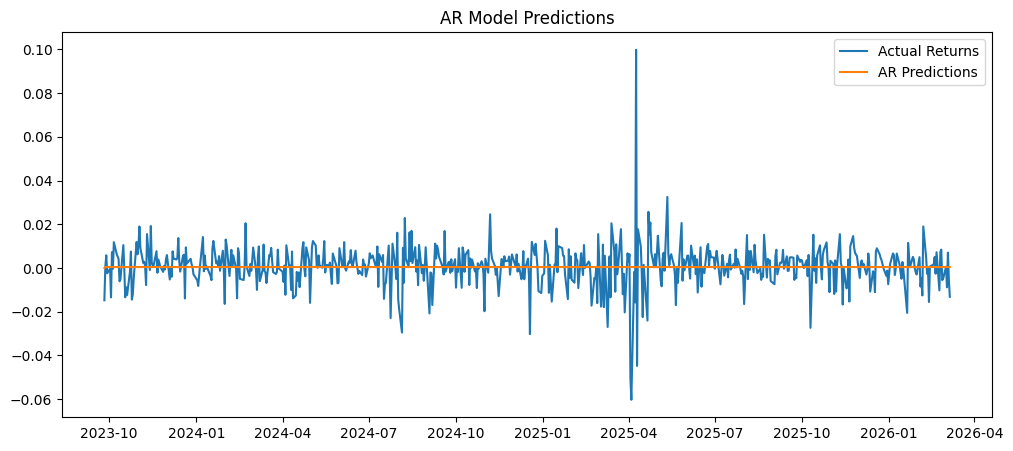

In [6]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Actual Returns")

plt.plot(test.index, ar_predictions, label="AR Predictions")

plt.legend()

plt.title("AR Model Predictions")

plt.show()

### AR Model Interpretation

The AR model captures only limited predictive structure in financial returns.

This is expected because financial returns typically exhibit weak autocorrelation and behave close to white noise.

## ARMA Model

The ARMA model combines autoregressive and moving average components.

This allows the model to capture both lagged dependencies and short-term shock effects.

In [7]:
arma_model = ARIMA(train, order=(1,0,1))

arma_result = arma_model.fit()

print(arma_result.summary())

c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2448
Model:                 ARIMA(1, 0, 1)   Log Likelihood                7552.803
Date:                Sun, 17 May 2026   AIC                         -15097.606
Time:                        17:16:00   BIC                         -15074.394
Sample:                             0   HQIC                        -15089.170
                               - 2448                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.929      0.054   -6.86e-06       0.001
ar.L1         -0.4776      0.048     -9.899      0.000      -0.572      -0.383
ma.L1          0.3615      0.052      6.962      0.0

In [8]:
arma_predictions = arma_result.predict(
    start=len(train),
    end=len(train) + len(test) - 1
)

c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Ananya_Hadimani\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


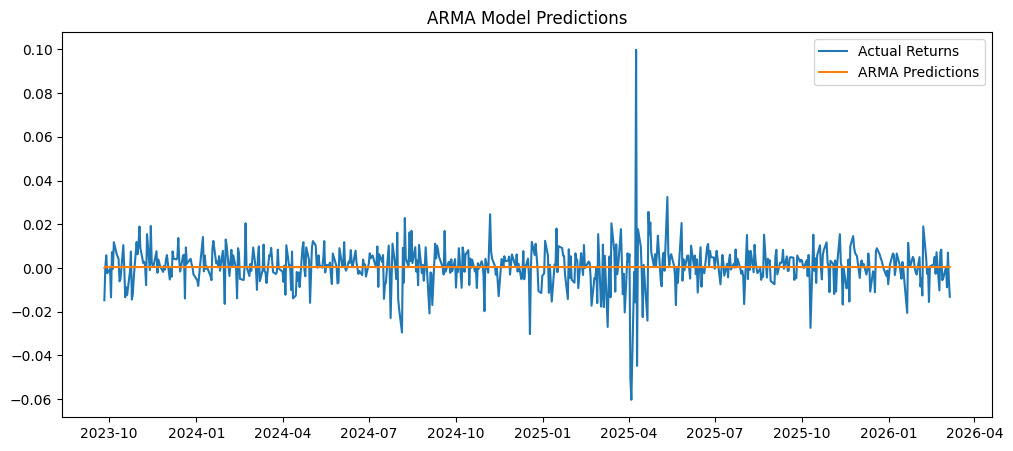

In [9]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Actual Returns")

plt.plot(test.index, arma_predictions, label="ARMA Predictions")

plt.legend()

plt.title("ARMA Model Predictions")

plt.show()

### ARMA Model Interpretation

The ARMA model provides only marginal improvements over the AR model.

The weak predictability confirms that financial returns contain very limited linear forecasting structure.

In [10]:
residuals = arma_result.resid

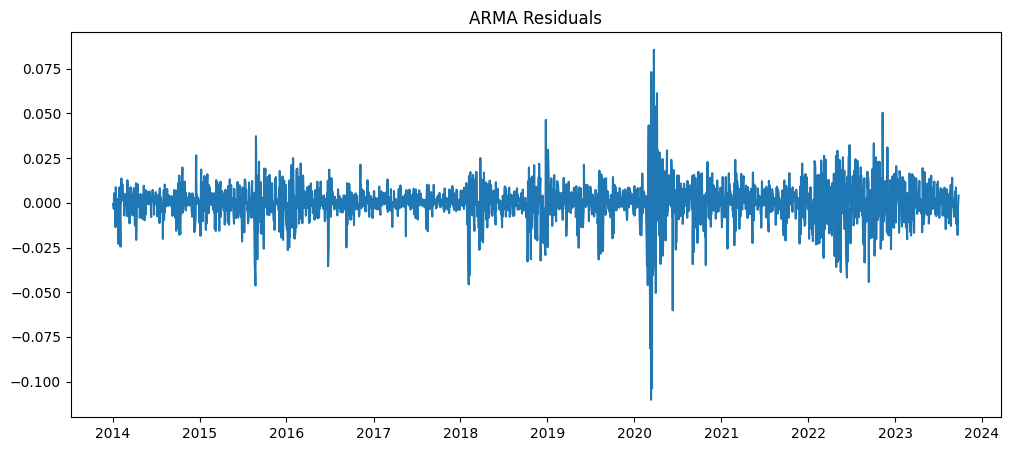

In [11]:
plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("ARMA Residuals")

plt.show()

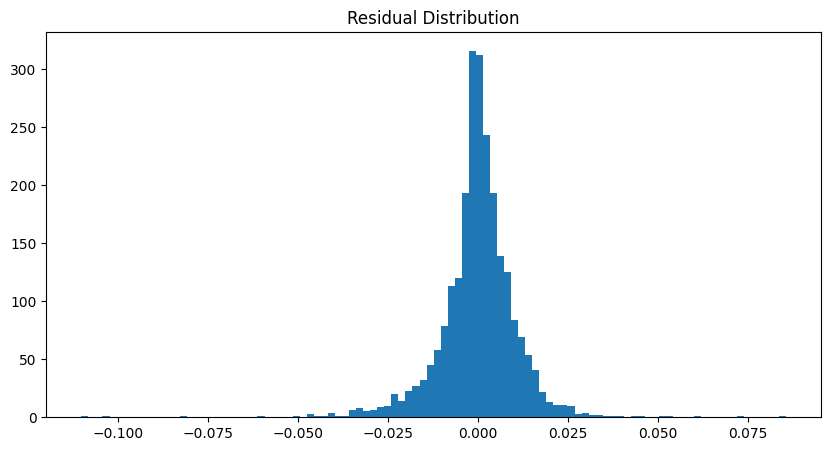

In [12]:
plt.figure(figsize=(10,5))

plt.hist(residuals, bins=100)

plt.title("Residual Distribution")

plt.show()

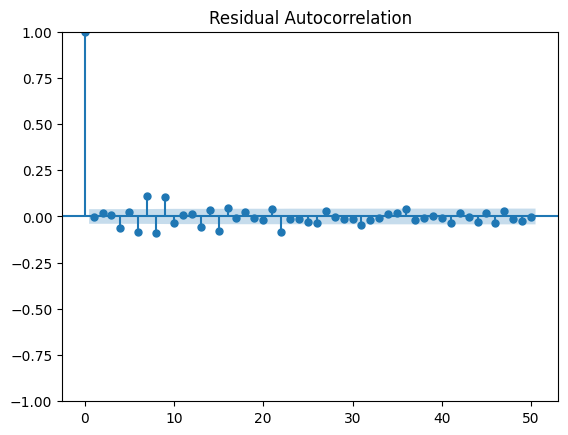

In [13]:
plot_acf(residuals, lags=50)

plt.title("Residual Autocorrelation")

plt.show()

### Residual Diagnostics

Residual autocorrelation is minimal after ARMA modeling.

This indicates that most linear mean structure has been removed from the series.

The residual series is now appropriate for volatility modeling using GARCH.

In [14]:
residual_df = pd.DataFrame({
    "residuals": residuals
})

residual_df.to_csv("../data/sp500_residuals.csv")

# Conclusion

The AR and ARMA models reveal that financial returns exhibit only weak linear predictability.

Most short-term mean dependence is minimal, supporting the view that returns behave close to white noise.

Residual diagnostics confirm that the remaining residual series is suitable for volatility modeling using GARCH-family models.